<a href="https://colab.research.google.com/github/bratzlernathan-cloud/lis4693/blob/main/Final%20Project/copy_of_final_project_draft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from itertools import combinations

##Installing necessary packages.

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

##Downloading required NLTK data packages including stopwords for filtering out common words, Wordnet for the lexical database used by the lemmatizer and punkt for the tokenizer model to split text in to individual words or sentences

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2019/2019-06-25/ufo_sightings.csv")
print(f"Total UFO reports: {len(df)}")


Total UFO reports: 80332


## Loading the UFO sightings dataset and printing the total number of reports from the dataset

In [ ]:

stop_words = set(stopwords.words('english'))
stop_words.update(['one', 'two', 'three', 'nuforc', 'quot', 'approximately', 'saw', 'looked', 'appeared', 'moved', 'seen', 'like', 'around', 'across', 'large', 'high', 'low', 'north', 'south', 'east', 'west', 'minute', 'second', 'ufo', 'sighting', 'object', 'craft', 'shape', 'note',
'near', 'area', 'direction', 'time', 'away', 'driving', 'observed', 'small', 'slow', 'wa', 'see'])
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text):
        return ''
    text = text.replace('&#44', ' ').replace('&amp;', ' ')
    text = re.sub(r'[^a-zA-Z\s]', ' ', text.lower()).strip()
    return text



##we started with the common stopwords, and then updated the stopwords to include numbers written as words, and UFO-specific terms that are to common in the dataset to be meaningful.
##We used the Lemmatizer to reduce words to their base form
##Cleaning the text to return an empty string if the text is missing or null replacing HTML encoded characters with spaces, and removing all non-alphabetic characters while converting to lowercase and trimming whitespace

In [ ]:
def preprocess(text):
    text = clean_text(text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word)
              for word in tokens
              if lemmatizer.lemmatize(word) not in stop_words and len(word) > 2]
    return ' '.join(tokens)

##Preprocessing the text for analysis by calling the clean text function and splitting in to individual word tokens
##Lemmatizing each word and filtering out the stopwords and words shorter than three characters.
##Returning tokens joined back in to a cleaned string.

In [ ]:
df['clean_description'] = df['description'].apply(clean_text)
df['processed'] = df['clean_description'].apply(preprocess)

print("Preprocessing completed successfully!")
print(df[['description', 'processed']].head())

Preprocessing completed successfully!
                                         description  \
0  This event took place in early fall around 194...   
1  1949 Lackland AFB&#44 TX.  Lights racing acros...   
2  Green/Orange circular disc over Chester&#44 En...   
3  My older brother and twin sister were leaving ...   
4  AS a Marine 1st Lt. flying an FJ4B fighter/att...   

                                           processed  
0  event took place early fall occurred boy scout...  
1  lackland afb light racing sky making degree tu...  
2         green orange circular disc chester england  
3  older brother twin sister leaving edna theater...  
4  marine flying fighter attack aircraft solo nig...  


##Applying clean text to the description column and storing the results in 'clean_description'
##Applying preprocess to the description column and storing the results in 'processed'

##confirming that preprocessing is completed and prints the first 5 rows and compares the original description to the processed description

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

##Importing CountVectorizer to convert the collection of documents into a matrix of token/word counts
##Importing LDA for topic modeling to discover hidden themes across a collection of documents by grouping frequently co-occurring words together.

In [ ]:
vectorizer = CountVectorizer(max_df=0.95, min_df=10, stop_words='english')
dtm = vectorizer.fit_transform(df['processed'])

##For the count vectorizer we are ignoring words that are in 95% of documents which are too common to be meaningful. We are also ignoring words that are in fewer than 10 documents which are too rare to be meaningful and filtering out stopwords

##Creating a document term matrix which is a numerical representation of the text in which each row is a UFO report and each column is a word with values representing word counts

##Fit transform learns the vocabulary from the processed descriptions and converts them to the matrix

In [ ]:
n_topics = 8
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(dtm)

LatentDirichletAllocation(n_components=8, random_state=42)

##We defined the number of topics as 8 that we want LDA to find in the dataset.

##Fit is training the LDA model on the Document term Matrix to discover the 8 topics by finding groups of words that frequently appear together accross the UFO reports.

In [ ]:
feature_names = vectorizer.get_feature_names_out()

print("\n=== Topics Found ===")
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-12:-1]]
    print(f"Topic {topic_idx}: {', '.join(top_words)}")


=== Topics Found ===
Topic 0: speed, possible, aircraft, new, jet, rate, sky, year, plane, flying, morning
Topic 1: light, orange, flying, bright, green, orb, ball, white, red, blue, round
Topic 2: fireball, orange, sphere, hovering, glowing, city, road, sighted, flying, mile, space
Topic 3: light, strange, bright, orange, red, white, witness, sky, beach, hovering, noise
Topic 4: star, light, sky, looking, noticed, night, outside, went, friend, home, thought
Topic 5: sky, light, bright, night, orange, disappeared, star, changed, moving, colored, slowly
Topic 6: shaped, triangle, light, triangular, black, disk, silver, cigar, white, silent, saucer
Topic 7: light, moving, red, sky, fast, bright, white, flashing, star, formation, blinking


##Feature names retrieves the full list of words learned by the vectorizer

##We are then looping through each of the 8 topics found by our LDA model and sorting word scores in descending order and taking the top 11 words
##Top words maps the indices back to their actual word names using feature names

##Printing each topic number followed by its 11 most representative words

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

##Importing the library for creating analyzing and visualizing network/graph structures
##Importing matplotlib to render and display network graphs


In [ ]:
all_words = ' '.join(df['processed']).split()
word_freq = Counter(all_words)
top_words = [word for word, freq in word_freq.most_common(50)]

## Joining all processed UFO reports in to one large string and splitting it in to a single list

##Counting how many times each word appears across all reports using Counter

# extracting just the word names of the 50 most frequent words to be used as the focus of the network graph

In [ ]:
G = nx.Graph()

for text in df['processed']:
    words_in_doc = [w for w in text.split() if w in top_words]
    for word1, word2 in combinations(set(words_in_doc), 2): #Avoiding duplicates
        if G.has_edge(word1, word2):
            G[word1][word2]['weight'] += 1
        else:
            G.add_edge(word1, word2, weight=1)

##Creating an empty undirected graph where nodes will be words and edges will be co-occurrences

##Looping through every processed UFO report and filtering each report down to only words that appear in the top 50 list of words
##The final result will show a graph where stronger connections mean two words appeared together more frequently across UFO reports

Network image saved as network.png


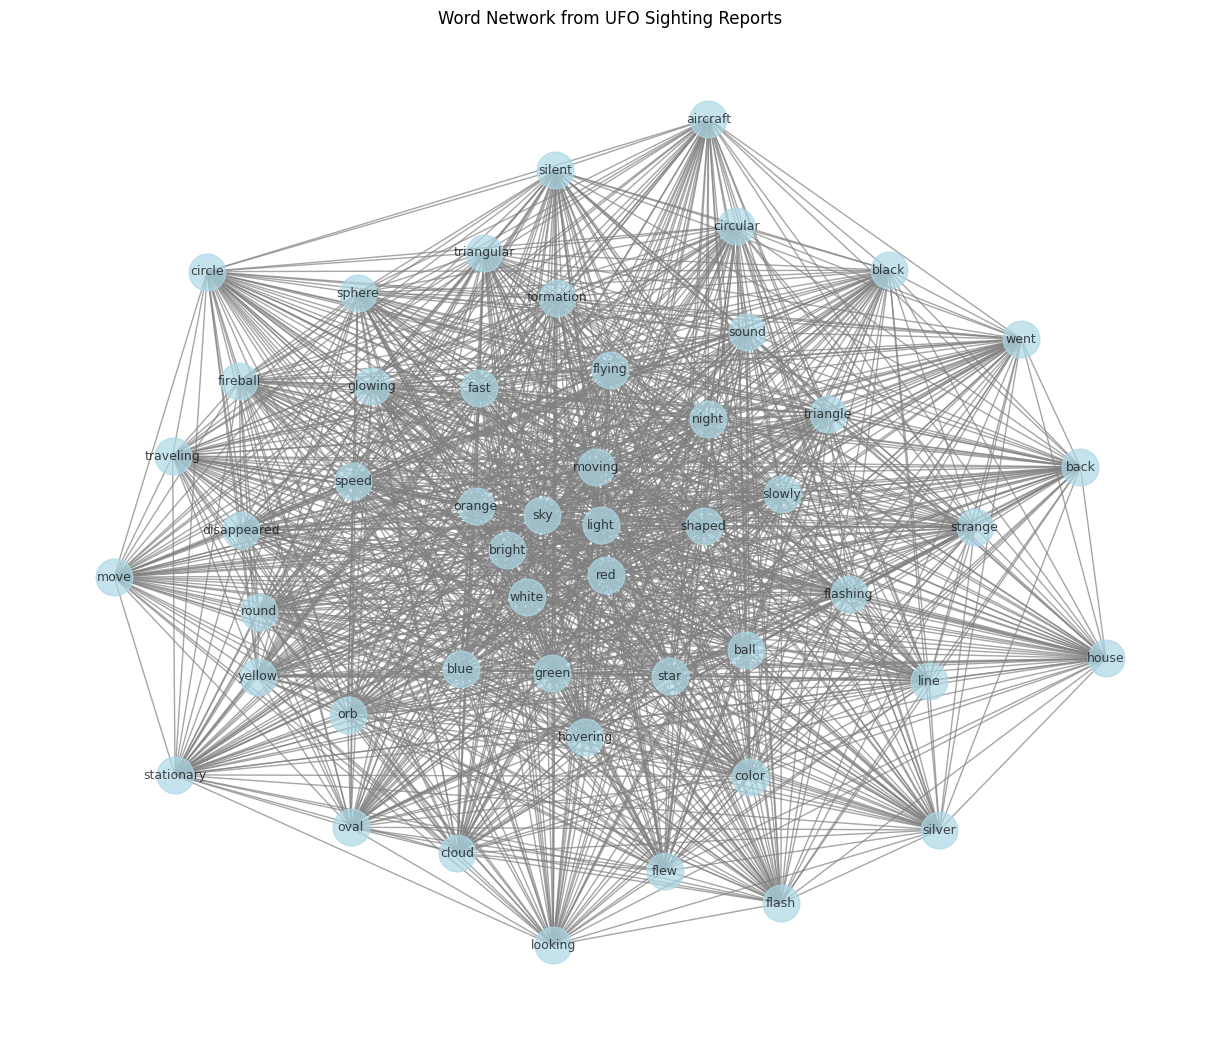

In [ ]:
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.6)
nx.draw(G, pos, with_labels=True, node_size=700, node_color='lightblue',
        font_size=9, edge_color='gray', alpha=0.7)
plt.title("Word Network from UFO Sighting Reports")
plt.savefig("network.png", dpi=300, bbox_inches='tight')
print("Network image saved as network.png")

##Graphing the word network created.
#we can see that the central words are the most interconnected and appear commonly alongside eachother. We can deduce that many UFO descriptions include seing a moving light through the sky described in different colors with red being the most common color seen.
##This could also be interpreted as people see aircraft with their red lights flying in the sky and mistake them for UFO's

In [ ]:
import altair as alt

top15 = pd.DataFrame(word_freq.most_common(15), columns=['word', 'count'])

chart = alt.Chart(top15).mark_bar(color='steelblue').encode(
    x=alt.X('count:Q', title='Frequency'),
    y=alt.Y('word:N', sort='-x', title='Word')
).properties(
    title='Most Common Words in UFO Reports',
    width=600,
    height=400
)

chart.display()

alt.Chart(...)

##Importing altair to have an interactive visualization library for creating charts and graphs.
##Graphing a horizontal bar chart where the x axis is the word frequency count and the y axis is the words sorted by frequency descending.

##We can see that light is the most requent word almost doubling the next most common word sky. This also confirms what our word network showed earlier with light and sky in the center of the word network appearing commonly.

In [ ]:
print(df.columns.tolist())

['date_time', 'city_area', 'state', 'country', 'ufo_shape', 'encounter_length', 'described_encounter_length', 'description', 'date_documented', 'latitude', 'longitude', 'clean_description', 'processed']


In [ ]:
df_ml = df.dropna(subset=['ufo_shape', 'processed'])
df_ml = df_ml[~df_ml['ufo_shape'].isin(['unknown', 'other'])]

shape_counts = df_ml['ufo_shape'].value_counts()
valid_shapes = shape_counts[shape_counts >= 50].index
df_ml = df_ml[df_ml['ufo_shape'].isin(valid_shapes)]

print(df_ml['ufo_shape'].value_counts())
print(f'Total records for ML: {len(df_ml)}')

ufo_shape
light        16565
triangle      7865
circle        7608
fireball      6208
sphere        5387
disk          5213
oval          3733
formation     2457
cigar         2057
changing      1962
flash         1328
rectangle     1297
cylinder      1283
diamond       1178
chevron        952
egg            759
teardrop       750
cone           316
cross          233
Name: count, dtype: int64
Total records for ML: 67151


##Creating a new dataframe for machine learning which drops any rows where UFO shape or processed text is missing.

##Also removing rows where UFO shape is unknown or other since these are not meaningful classes for a classifier to learn from.

##Counting how many reports exist for each shape, and keeping only shapes that appear at least 50 times to ensure the model has enough examples per class to learn from.

##Filtering down to only rows with a valid frequent enough shape.

##Printing the count of each remaining UFO shape and the total number of records available for machine learning.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


x = df_ml['processed']
y = df_ml['ufo_shape']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = .3, random_state = 42, stratify =y)

x_train = x_train.fillna('')
x_test = x_test.fillna('')

preprocessing = Pipeline([
    ('vect', CountVectorizer(ngram_range=(1,2), max_features=50000)),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(x_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(x_test)

print("Training Logistic Regression classifier...")
lr_classifier = LogisticRegression(max_iter=1000)
lr_classifier.fit(train_preprocessed, y_train)

y_pred = lr_classifier.predict(test_preprocessed)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Preprocessing training data...
Preprocessing test data...
Training Logistic Regression classifier...

Accuracy: 0.5521

Classification Report:
              precision    recall  f1-score   support

    changing       0.54      0.10      0.17       589
     chevron       0.79      0.39      0.52       286
       cigar       0.88      0.48      0.62       617
      circle       0.42      0.35      0.38      2282
        cone       0.86      0.32      0.46        95
       cross       0.81      0.19      0.30        70
    cylinder       0.84      0.36      0.50       385
     diamond       0.86      0.43      0.57       353
        disk       0.53      0.54      0.53      1564
         egg       0.92      0.38      0.54       228
    fireball       0.72      0.61      0.66      1862
       flash       0.62      0.33      0.43       398
   formation       0.47      0.22      0.30       737
       light       0.46      0.84      0.59      4970
        oval       0.75      0.37      0.50   

##Importing necessary packages such as test train split, pipeline, logistic regression and classification report, confusion matrix, and accuracy score

##Setting the processed text description used as the features or input
##Setting UFO shape as the target label or output (What we want to predict)

##Splitting the data in to a test and train set. We will split to a 70% training and 30% testing. Using stratify=y to ensure that each UFO shape is proportionally represented in both the training and test sets

##Using fillna to replace any remaining null values with empty strings to prevent errors during vectorization

##using count vectorizer to convert text in to word/bigram count matrix which captures single words and two word phrases. We also limited vocabulary to the 50000 most frequent terms

##The TfidfTransformer converts raw counts to TF-IDF scores, which down weights common words and up weights distinctive ones.

##Fit transform learns vocabulary and TF-IDF weights from training data and transforms it. Transform applies the already learned vocabulary and wieghts it to the test data.

#Logistic Regression was our model of choice. We used max_iter=1000 which allows up to 1000 iterations for the model to converge. Fit() trains the classifier on the preprocessed training data and predict() generates UFO shape predictions for the test set.

##Printing the overall acuraccy score and full classification report showing the overall scores of the model.

## We chose logistic regression over SVM and Naive Bayes as it was the most accurate. After making some changes we were able to raise the accuracy to 55% from its initial 48%. One way we would be able to make the model even more accurate is to introduce more datasets for learning. Currently light has the most support with 4970 reports and a high recall, but low prescision meaning the model is over predicting light defaulting to it since its the most common class.

##Introducing more datasets would be a good way to increase overall scores since we would be able to get more examples of other shapes which are underrepresented in this dataset.

##Triangle, Cigar, and Fireball have the highest overall scores.

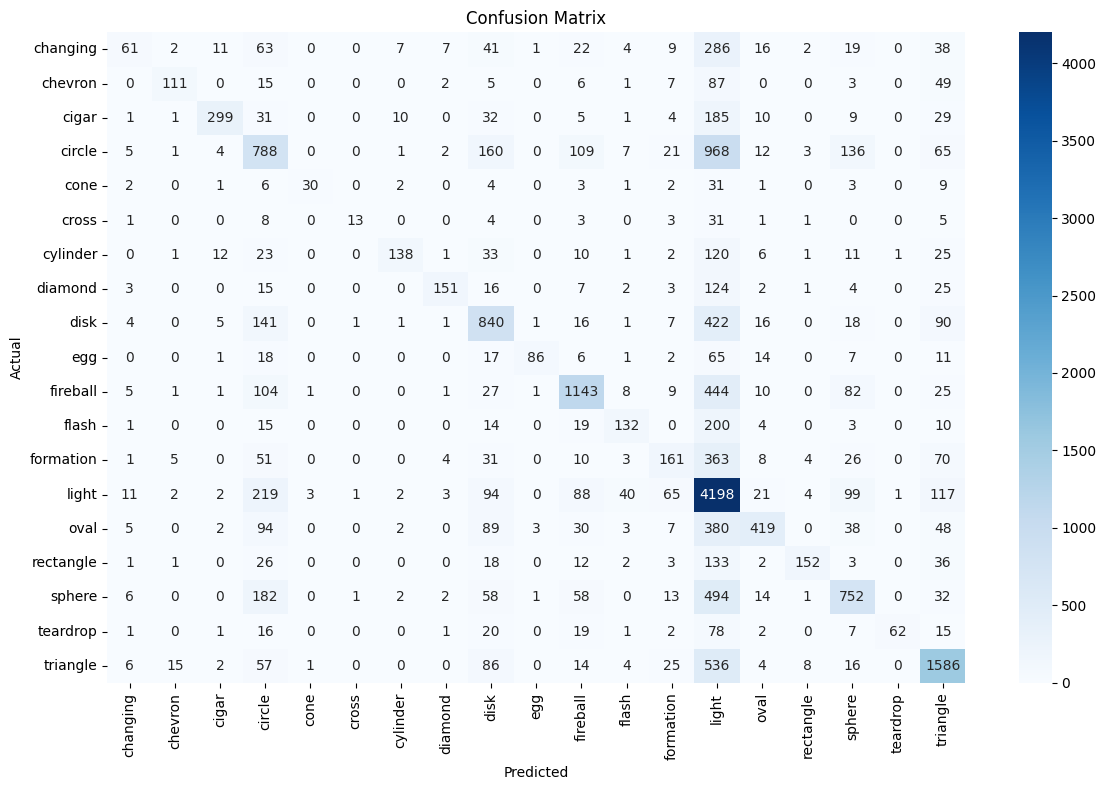

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels = lr_classifier.classes_)
plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt= 'd', xticklabels = lr_classifier.classes_,
            yticklabels=lr_classifier.classes_, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Computing the confusion matrix comparing actual vs predicted UFO shapes. Rows represent the actual shape, and columns represent the predicted shape. And diagonal values are correct predictions.

##Light had the most correct predictions, but the model is picking light often which shows why it correctly picked light but also picked light when it was actually a different shape. Once again this would be remedied by introducing more datasets to the model.